<a href="https://colab.research.google.com/github/OnwutaKelvin/ML-notebooks/blob/main/Brain_MRI_Tumors_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import json
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

import torch

from sklearn.model_selection import train_test_split

GETTING THE DATA PATH

In [ ]:
dataset_path = kagglehub.dataset_download("fernando2rad/brain-tumor-mri-images-30-classes")
print("Path to dataset:", dataset_path)

100%|██████████| 478M/478M [00:04<00:00, 118MB/s] 

Extracting files...


Path to dataset: /root/.cache/kagglehub/datasets/fernando2rad/brain-tumor-mri-images-30-classes/versions/1


In [ ]:
print(os.listdir(dataset_path))

['Other T2', 'Normal T1C+', 'Hemangiopericytoma T2', 'Meningioma T1', 'Neurocytoma T2', 'Oligodendroglioma T1', 'Schwannoma T1C+', 'Normal T2', 'DATA.json', 'Normal T1', 'Astrocytoma T1', 'Glioma T1', 'Glioma T1C+', 'Ependymoma T1C+', 'Astrocytoma T1C+', 'Astrocytoma T2', 'Oligodendroglioma T1C+', 'Oligodendroglioma T2', 'Ependymoma T2', 'Other T1C+', 'Neurocytoma T1C+', 'Meningioma T2', 'Schwannoma T2', 'Schwannoma T1', 'Other T1', 'Hemangiopericytoma T1C+', 'Hemangiopericytoma T1', 'Meningioma T1C+', 'Ependymoma T1', 'Glioma T2', 'Neurocytoma T1']


CHECKING THE NUMBER OF FILES IN THE DATASET

In [ ]:
for root, dirs, files in os.walk(dataset_path):
  print(root, "__", len(files), "files")

/root/.cache/kagglehub/datasets/fernando2rad/brain-tumor-mri-images-30-classes/versions/1 __ 1 files
/root/.cache/kagglehub/datasets/fernando2rad/brain-tumor-mri-images-30-classes/versions/1/Other T2 __ 365 files
/root/.cache/kagglehub/datasets/fernando2rad/brain-tumor-mri-images-30-classes/versions/1/Normal T1C+ __ 264 files
/root/.cache/kagglehub/datasets/fernando2rad/brain-tumor-mri-images-30-classes/versions/1/Hemangiopericytoma T2 __ 118 files
/root/.cache/kagglehub/datasets/fernando2rad/brain-tumor-mri-images-30-classes/versions/1/Meningioma T1 __ 636 files
/root/.cache/kagglehub/datasets/fernando2rad/brain-tumor-mri-images-30-classes/versions/1/Neurocytoma T2 __ 174 files
/root/.cache/kagglehub/datasets/fernando2rad/brain-tumor-mri-images-30-classes/versions/1/Oligodendroglioma T1 __ 221 files
/root/.cache/kagglehub/datasets/fernando2rad/brain-tumor-mri-images-30-classes/versions/1/Schwannoma T1C+ __ 564 files
/root/.cache/kagglehub/datasets/fernando2rad/brain-tumor-mri-images-3

COUNTING THE TOTAL NO. OF IMAGE FILE IN THE DATASET

In [ ]:
from collections import Counter

all_image_path = []

for root, _, files in os.walk(dataset_path):
  for file in files:
    if file.lower().endswith(( 'jpg', 'jpeg')):
      full_path = os.path.join(root, file)
      all_image_path.append(full_path)

#count extensions for collected image path
all_image_extensions = [os.path.splitext(p)[1].lower() for p in all_image_path]
extensions_count = Counter(all_image_extensions)

print("All image path found:", len(all_image_path))
print("All extension counts:", extensions_count)

All image path found: 11300
All extension counts: Counter({'.jpg': 11300})


LOADING THE DATASET ON A DATAFRAME

In [ ]:
df = pd.DataFrame({"image_path" : all_image_path})
display(df.head())

,image_path
0,/root/.cache/kagglehub/datasets/fernando2rad/b...
1,/root/.cache/kagglehub/datasets/fernando2rad/b...
2,/root/.cache/kagglehub/datasets/fernando2rad/b...
3,/root/.cache/kagglehub/datasets/fernando2rad/b...
4,/root/.cache/kagglehub/datasets/fernando2rad/b...


In [ ]:
#Creating a label from the file name directory
df["label"] = df["image_path"].apply(lambda x: os.path.basename(os.path.dirname(x)))
display(df["label"].head())

,label
0,Other T2
1,Other T2
2,Other T2
3,Other T2
4,Other T2


In [ ]:
#Data shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 11300
Columns: 2


In [ ]:
#Missing Values
df.isnull().sum()

,0
image_path,0
label,0


In [ ]:
#Duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
#class counts
class_counts = df["label"].value_counts()
print(class_counts)

label
Meningioma T1C+            977
Other T1C+                 756
Meningioma T1              636
Schwannoma T1C+            564
Glioma T1C+                549
Glioma T1                  522
Meningioma T2              458
Astrocytoma T1C+           441
Normal T1                  415
Other T1                   412
Glioma T2                  405
Astrocytoma T1             396
Normal T2                  379
Ependymoma T1C+            374
Other T2                   365
Schwannoma T1              363
Ependymoma T2              350
Ependymoma T1              313
Schwannoma T2              309
Hemangiopericytoma T1C+    307
Astrocytoma T2             281
Normal T1C+                264
Neurocytoma T1C+           254
Oligodendroglioma T1       221
Oligodendroglioma T1C+     192
Neurocytoma T1             190
Hemangiopericytoma T1      178
Neurocytoma T2             174
Oligodendroglioma T2       137
Hemangiopericytoma T2      118
Name: count, dtype: int64


In [ ]:
#Number of Class
no_of_class = df["label"].nunique()
print("Number of Classes:", no_of_class)

Number of Classes: 30


In [ ]:
#Extract no of Weightings
def extract_weight(label):
  if "T1C+" in label:
    return "T1C+"
  elif "T1" in label:
    return "T1"
  elif "T2" in label:
    return "T2"
  else:
    return "Unknown"

df["weightings"] = df["label"].apply(extract_weight)
df.head()

,image_path,label,weightings
0,/root/.cache/kagglehub/datasets/fernando2rad/b...,Other T2,T2
1,/root/.cache/kagglehub/datasets/fernando2rad/b...,Other T2,T2
2,/root/.cache/kagglehub/datasets/fernando2rad/b...,Other T2,T2
3,/root/.cache/kagglehub/datasets/fernando2rad/b...,Other T2,T2
4,/root/.cache/kagglehub/datasets/fernando2rad/b...,Other T2,T2


In [ ]:
#Weighting count
df["weightings"].value_counts()

,count
weightings,
T1C+,4678
T1,3646
T2,2976


In [ ]:
#Extract Tumor Types from the label
def extract_tumor_types(label):
  return label.replace("T1C+","").replace("T1", "").replace("T2", "").strip()

df["tumor_type"] = df["label"].apply(extract_tumor_types)
df.head()

,image_path,label,weightings,tumor_type
0,/root/.cache/kagglehub/datasets/fernando2rad/b...,Other T2,T2,Other
1,/root/.cache/kagglehub/datasets/fernando2rad/b...,Other T2,T2,Other
2,/root/.cache/kagglehub/datasets/fernando2rad/b...,Other T2,T2,Other
3,/root/.cache/kagglehub/datasets/fernando2rad/b...,Other T2,T2,Other
4,/root/.cache/kagglehub/datasets/fernando2rad/b...,Other T2,T2,Other


In [ ]:
#Tumor type count
df["tumor_type"].value_counts()


,count
tumor_type,
Meningioma,2071
Other,1533
Glioma,1476
Schwannoma,1236
Astrocytoma,1118
Normal,1058
Ependymoma,1037
Neurocytoma,618
Hemangiopericytoma,603


In [ ]:
# Normal vs Tumor
df["binary_label"] = df["tumor_type"].apply(lambda x: "Normal" if x == "Normal" else "Tumor")
df.head()

,image_path,label,weightings,tumor_type,binary_label
0,/root/.cache/kagglehub/datasets/fernando2rad/b...,Other T2,T2,Other,Tumor
1,/root/.cache/kagglehub/datasets/fernando2rad/b...,Other T2,T2,Other,Tumor
2,/root/.cache/kagglehub/datasets/fernando2rad/b...,Other T2,T2,Other,Tumor
3,/root/.cache/kagglehub/datasets/fernando2rad/b...,Other T2,T2,Other,Tumor
4,/root/.cache/kagglehub/datasets/fernando2rad/b...,Other T2,T2,Other,Tumor


In [ ]:
#Normal vs Tumor count
df["binary_label"].value_counts()

,count
binary_label,
Tumor,10242
Normal,1058


In [ ]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

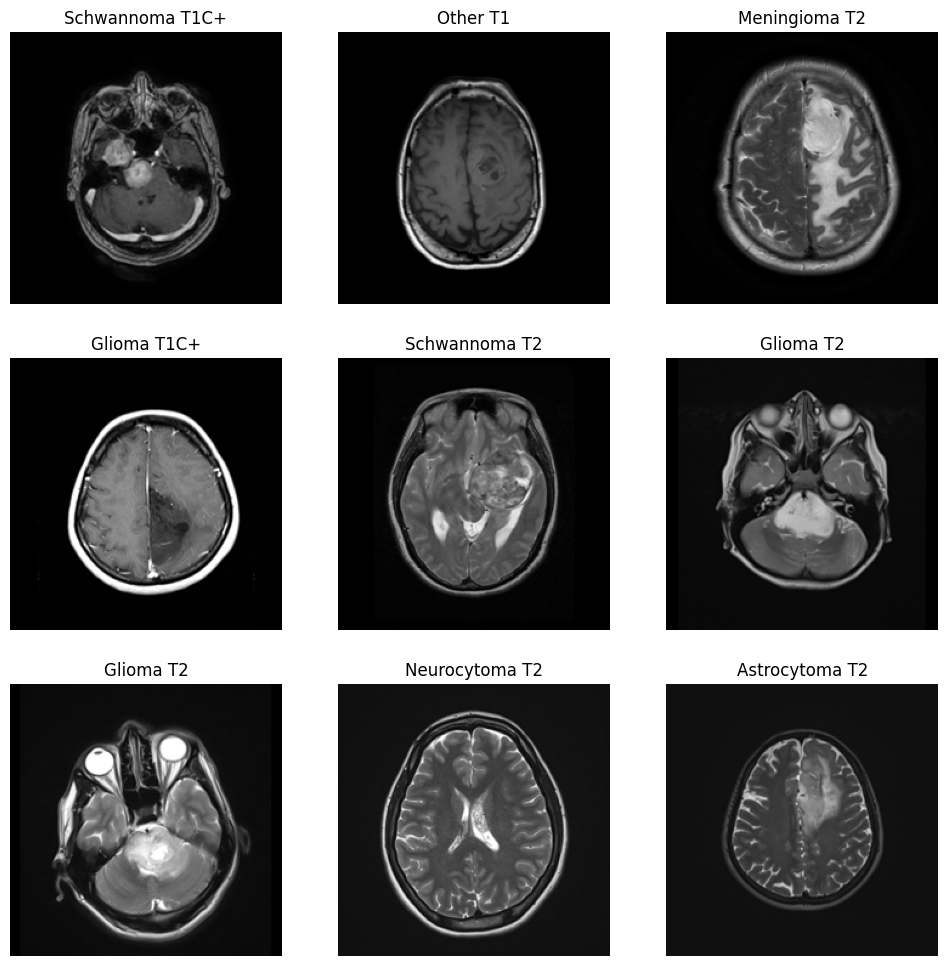

In [ ]:
#Plotting samples
from PIL import Image

sample_df = df.sample(min(9, len(df)), random_state=seed)

plt.figure(figsize=(12, 12))

for i, row in enumerate(sample_df.itertuples()):
  img = Image.open(row.image_path).resize((224, 224))
  plt.subplot(3, 3, i+1)
  plt.imshow(img, cmap="gray")
  plt.title(row.label)
  plt.axis("off")

plt.show()

In [ ]:
#Image size check
sizes = []
for path in df["image_path"].sample(min(50, len(df)), random_state=seed):
  img = Image.open(path)
  sizes.append(img.size)

pd.Series(sizes).value_counts().head()


,count
"(512, 512)",50


In [ ]:
print(img.mode)

RGB


In [ ]:
#Device
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
print(device)

cuda


In [ ]:
from torchvision import transforms
#Data Augumentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

#Datasets differnetiation
#Dataset
train_df, test_df = train_test_split(
    df,
    train_size=0.9,
    stratify=df['label'],
    random_state=seed

)

#train and validation split
train_df, val_df = train_test_split(
    train_df,
    train_size=0.8, # 0.8 of the current train_df, which is 0.8 * 0.9 = 0.72 of the original df
    stratify=train_df['label'], # Stratify based on the label within this subset
    random_state=seed
)

print("Train Shape:", train_df.shape)
print("Val Shape:", val_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (8136, 5)
Val Shape: (2034, 5)
Test Shape: (1130, 5)


In [ ]:
#Indexing labels
unique_labels = df["label"].unique()
label_to_index = {
    label: index
    for index, label in enumerate(unique_labels)
}

index_to_label = {
    index: label
    for index, label in enumerate(unique_labels)
}

num_of_classes = len(unique_labels)

print("Labels and its index:", label_to_index)
print("Number of classes:", num_of_classes)

Labels and its index: {'Other T2': 0, 'Normal T1C+': 1, 'Hemangiopericytoma T2': 2, 'Meningioma T1': 3, 'Neurocytoma T2': 4, 'Oligodendroglioma T1': 5, 'Schwannoma T1C+': 6, 'Normal T2': 7, 'Normal T1': 8, 'Astrocytoma T1': 9, 'Glioma T1': 10, 'Glioma T1C+': 11, 'Ependymoma T1C+': 12, 'Astrocytoma T1C+': 13, 'Astrocytoma T2': 14, 'Oligodendroglioma T1C+': 15, 'Oligodendroglioma T2': 16, 'Ependymoma T2': 17, 'Other T1C+': 18, 'Neurocytoma T1C+': 19, 'Meningioma T2': 20, 'Schwannoma T2': 21, 'Schwannoma T1': 22, 'Other T1': 23, 'Hemangiopericytoma T1C+': 24, 'Hemangiopericytoma T1': 25, 'Meningioma T1C+': 26, 'Ependymoma T1': 27, 'Glioma T2': 28, 'Neurocytoma T1': 29}
Number of classes: 30


In [ ]:
#Dataset Pipeline
from torch.utils.data import Dataset

class BrainTumorDataset(Dataset):
  def __init__(self, dataframe, transform=None):
    self.dataframe = dataframe
    self.transform = transform

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx]['image_path'] # Changed 'img_path' to 'image_path'
    label = self.dataframe.iloc[idx]['label']

    image = Image.open(img_path).convert("RGB")  #convert images to rgb to maintain consistency

    if self.transform:
      image = self.transform(image)

    label_idx = label_to_index[label]  #convert string label to integer index
    return image, label_idx

In [ ]:
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count() # Use all available CPU cores as workers

# Instantiate datasets
train_dataset_obj = BrainTumorDataset(train_df, train_transform)
val_dataset_obj = BrainTumorDataset(val_df, test_transform)
test_dataset_obj = BrainTumorDataset(test_df, test_transform)

# Loading Datasets
train_loader = DataLoader(
    train_dataset_obj,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset_obj,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset_obj,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Number of training batches: 255
Number of validation batches: 64
Number of test batches: 36


In [ ]:
#RESIDUAL BLOCK
import torch.nn as nn
import torch

class ResidualBlock(nn.Module):
  def __init__(self, in_channels, out_channels, stride=1):
    super().__init__()

    # Main path
    self.conv1 = nn.Conv2d(
        in_channels,
        out_channels,
        kernel_size=3,
        padding=1,
        stride=stride, # Apply stride here for downsampling
        bias=False
    )
    self.bn1 = nn.BatchNorm2d(out_channels)

    self.conv2 = nn.Conv2d(
        out_channels,
        out_channels,
        kernel_size=3,
        padding=1,
        stride=1, # Second conv in block always uses stride 1
        bias=False
    )
    self.bn2 = nn.BatchNorm2d(out_channels)

    # Shortcut path
    self.shortcut = nn.Sequential()
    if stride != 1 or in_channels != out_channels:
      self.shortcut = nn.Sequential(
          nn.Conv2d(
              in_channels,
              out_channels,
              kernel_size=1, # Use 1x1 convolution for projection
              stride=stride, # Apply stride here for downsampling
              bias=False
          ),
          nn.BatchNorm2d(out_channels)
      )

  def forward(self, x):
    identity = self.shortcut(x)

    out = self.conv1(x)
    out = self.bn1(out)
    out = torch.relu(out)

    out = self.conv2(out)
    out = self.bn2(out)

    out += identity  # adding the conv output to the original
    out = torch.relu(out)

    return out

In [ ]:
#RESNET 18
class ResNet(nn.Module):
  def __init__(self, num_classes):
    super().__init__()

    self.in_channels = 64

    #Initial stem layer
    self.conv1 = nn.Conv2d(
        3,
        64,
        kernel_size=3,
        padding=1,
        stride=1,
        bias=False
    )
    self.bn1 = nn.BatchNorm2d(64)

    #Residual Layer
    self.layer1 = self._make_layer(64, 2, stride=1)
    self.layer2 = self._make_layer(128, 2, stride=2)
    self.layer3 = self._make_layer(256, 2, stride=2)
    self.layer4 = self._make_layer(512, 2, stride=2)

    self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

    self.fc = nn.Linear(512, num_classes)

  def _make_layer(self, out_channels, blocks, stride):
    layers = []

    #First block may downsample
    layers.append(
        ResidualBlock(
            self.in_channels,
            out_channels,
            stride
        )
    )
    self.in_channels = out_channels

    #Remaining Blocks
    for _ in range(1, blocks):
      layers.append(
          ResidualBlock(
              self.in_channels,
              out_channels
          )
      )
    return nn.Sequential(*layers)

  def forward(self, x):
    x = self.conv1(x)
    x = self.bn1(x)
    x = torch.relu(x)

    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.layer4(x)

    x = self.avgpool(x)

    x = torch.flatten(x, 1)
    x = self.fc(x)

    return x

RESNET WITH DROPOUT FOR FINE TUNING

In [ ]:
!pip install torchinfo

import torchinfo

from torchinfo import summary

class ResNet_Dropout(ResNet):
    def __init__(self, num_classes=30, dropout_rate=0.4):
        super().__init__(num_classes)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = torch.relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        x = torch.flatten(x, 1)

        # Apply dropout before the final classification layer
        x = self.dropout(x)
        x = self.fc(x)

        return x

# Instantiate the new model with dropout
model_ft = ResNet_Dropout(num_classes=num_of_classes).to(device)

# Freeze all parameters initially
for param in model_ft.parameters():
    param.requires_grad = False

# Unfreeze only the specified layers
for param in model_ft.layer4.parameters():
  param.requires_grad = True
for param in model_ft.fc.parameters():
  param.requires_grad = True

print("Model with Dropout instantiated. Only the final layer is trainable.")
summary(model_ft, input_size=(BATCH_SIZE, 3, 224, 224))

Model with Dropout instantiated. Only the final layer is trainable.


Layer (type:depth-idx)                   Output Shape              Param #
ResNet_Dropout                           [32, 30]                  --
├─Conv2d: 1-1                            [32, 64, 224, 224]        (1,728)
├─BatchNorm2d: 1-2                       [32, 64, 224, 224]        (128)
├─Sequential: 1-3                        [32, 64, 224, 224]        --
│    └─ResidualBlock: 2-1                [32, 64, 224, 224]        --
│    │    └─Sequential: 3-1              [32, 64, 224, 224]        --
│    │    └─Conv2d: 3-2                  [32, 64, 224, 224]        (36,864)
│    │    └─BatchNorm2d: 3-3             [32, 64, 224, 224]        (128)
│    │    └─Conv2d: 3-4                  [32, 64, 224, 224]        (36,864)
│    │    └─BatchNorm2d: 3-5             [32, 64, 224, 224]        (128)
│    └─ResidualBlock: 2-2                [32, 64, 224, 224]        --
│    │    └─Sequential: 3-6              [32, 64, 224, 224]        --
│    │    └─Conv2d: 3-7                  [32, 64, 224, 224]

In [ ]:
#Label Smoothing
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1  #label smoothing reduces model overconfidence and improves generalization
)

In [ ]:
#Optimizer + Weight decay
optimizer = torch.optim.SGD(
    model_ft.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4  #weight decay discourages large weights and prevents overfitting
)

In [ ]:
#LEARNING RATE SCHEDULER
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50
)

In [ ]:
#MIXED PRECISION TRAINING
#torch.cuda.amp.autocast()
scaler = torch.amp.GradScaler('cuda')   #faster training, less gpu memory, identical accuracy

In [ ]:
from tqdm import tqdm

# Optimizer for fine-tuning (only updating trainable parameters)
optimizer_ft = torch.optim.SGD(
    filter(lambda p: p.requires_grad, model_ft.parameters()),
    lr=0.01, # Often a smaller learning rate is used for fine-tuning
    momentum=0.9,
    weight_decay=5e-4
)

# Learning Rate Scheduler for fine-tuning
scheduler_ft = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ft,
    T_max=20 # Max epochs for fine-tuning
)

epochs_ft = 20 # Number of epochs for fine-tuning
best_val_acc_ft = 0

train_losses_ft = []
val_losses_ft = []
train_accuracies_ft = []
val_accuracies_ft = []

print(f"\nStarting fine-tuning for {epochs_ft} epochs...")

for epoch_ft in range(epochs_ft):
  model_ft.train()

  running_loss_ft = 0
  correct_ft = 0
  total_ft = 0

  loop_ft = tqdm(train_loader, leave=True) # Set leave=True to keep the final state of the progress bar

  for images, labels in loop_ft:
    images = images.to(device)
    labels = labels.to(device)

    optimizer_ft.zero_grad()

    with torch.cuda.amp.autocast(): # Use mixed precision if available
      outputs_ft = model_ft(images)
      loss_ft = criterion(outputs_ft, labels)

    scaler.scale(loss_ft).backward()
    scaler.step(optimizer_ft)
    scaler.update()

    running_loss_ft += loss_ft.item()

    _, predicted_ft = torch.max(outputs_ft, 1)

    total_ft += labels.size(0)
    correct_ft += (predicted_ft == labels).sum().item()

    # Update tqdm description and postfix
    loop_ft.set_description(f"Epoch FT [{epoch_ft+1}/{epochs_ft}] (Training)")
    loop_ft.set_postfix(
        loss=running_loss_ft / (loop_ft.n + 1),
        acc=(100. * correct_ft / total_ft) if total_ft > 0 else 0
    )

  # Calculate epoch-wise training metrics
  train_loss_epoch_ft = running_loss_ft / len(train_loader)
  train_acc_epoch_ft = 100. * correct_ft / total_ft

  # VALIDATION LOOP for fine-tuning
  model_ft.eval()

  val_running_loss_ft = 0
  val_correct_ft = 0
  val_total_ft = 0

  with torch.no_grad():
    val_loop_ft = tqdm(val_loader, leave=True) # Use a separate tqdm for validation
    for images, labels in val_loop_ft:
      images = images.to(device)
      labels = labels.to(device)

      outputs_ft = model_ft(images)
      loss_ft = criterion(outputs_ft, labels) # Calculate loss for validation

      val_running_loss_ft += loss_ft.item()

      _, predicted_ft = torch.max(outputs_ft, 1)

      val_total_ft += labels.size(0)
      val_correct_ft += (predicted_ft == labels).sum().item()

      # Update tqdm description and postfix for validation
      val_loop_ft.set_description(f"Epoch FT [{epoch_ft+1}/{epochs_ft}] (Validation)")
      val_loop_ft.set_postfix(
          loss=val_running_loss_ft / (val_loop_ft.n + 1),
          acc=(100. * val_correct_ft / val_total_ft) if val_total_ft > 0 else 0
      )

  # Calculate epoch-wise validation metrics
  val_loss_epoch_ft = val_running_loss_ft / len(val_loader)
  val_acc_epoch_ft = 100. * val_correct_ft / val_total_ft

  # Store metrics
  train_losses_ft.append(train_loss_epoch_ft)
  val_losses_ft.append(val_loss_epoch_ft)
  train_accuracies_ft.append(train_acc_epoch_ft)
  val_accuracies_ft.append(val_acc_epoch_ft)

  print(
      f"\nEpoch FT [{epoch_ft+1}/{epochs_ft}] | "
      f"Train Loss: {train_loss_epoch_ft:.4f} | Train Acc: {train_acc_epoch_ft:.2f}% | "
      f"Val Loss: {val_loss_epoch_ft:.4f} | Val Acc: {val_acc_epoch_ft:.2f}%"
  )

  # Save the best fine-tuned model
  if val_acc_epoch_ft > best_val_acc_ft:
    best_val_acc_ft = val_acc_epoch_ft

    torch.save(
        model_ft.state_dict(),
        "best_finetuned_model.pth"
    )
    print("Best Fine-tuned Model Saved!")

  # Step the learning rate scheduler
  scheduler_ft.step()


Starting fine-tuning for 20 epochs...


  0%|          | 0/255 [00:00<?, ?it/s]/tmp/ipykernel_588/875228971.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(): # Use mixed precision if available
Epoch FT [1/20] (Validation): 100%|██████████| 64/64 [00:22<00:00,  2.90it/s, acc=16, loss=3.01]



Epoch FT [1/20] | Train Loss: 3.1136 | Train Acc: 14.32% | Val Loss: 3.0147 | Val Acc: 15.98%
Best Fine-tuned Model Saved!


Epoch FT [2/20] (Validation): 100%|██████████| 64/64 [00:22<00:00,  2.85it/s, acc=29.7, loss=2.54]



Epoch FT [2/20] | Train Loss: 2.6354 | Train Acc: 26.32% | Val Loss: 2.5365 | Val Acc: 29.74%
Best Fine-tuned Model Saved!


...


Epoch FT [18/20] | Train Loss: 1.3548 | Train Acc: 78.69% | Val Loss: 1.2674 | Val Acc: 82.20%
Best Fine-tuned Model Saved!


Epoch FT [19/20] (Validation): 100%|██████████| 64/64 [00:24<00:00,  2.65it/s, acc=81.7, loss=1.26]



Epoch FT [19/20] | Train Loss: 1.3262 | Train Acc: 79.98% | Val Loss: 1.2587 | Val Acc: 81.66%


Epoch FT [20/20] (Validation): 100%|██████████| 64/64 [00:24<00:00,  2.62it/s, acc=82.3, loss=1.24]


Epoch FT [20/20] | Train Loss: 1.3125 | Train Acc: 80.47% | Val Loss: 1.2404 | Val Acc: 82.25%
Best Fine-tuned Model Saved!


In [ ]:
model_ft.eval() # Set the model to evaluation mode

test_correct = 0
test_total = 0

print("\nStarting inference on test data...")

with torch.no_grad(): # Disable gradient calculations during inference
  test_loop = tqdm(test_loader, leave=True) # Progress bar for test set
  for images, labels in test_loop:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model_ft(images)
    _, predicted = torch.max(outputs.data, 1)

    test_total += labels.size(0)
    test_correct += (predicted == labels).sum().item()

    test_loop.set_description("Inference")
    test_loop.set_postfix(acc=(100. * test_correct / test_total) if test_total > 0 else 0)

test_accuracy = 100. * test_correct / test_total
print(f"\nAccuracy of the fine-tuned model on the test images: {test_accuracy:.2f}%")


Starting inference on test data...


Inference: 100%|██████████| 36/36 [00:13<00:00,  2.60it/s, acc=82.1]


Accuracy of the fine-tuned model on the test images: 82.12%


In [ ]:
import matplotlib.pyplot as plt

# Plot Loss Curves for Fine-tuning
plt.figure(figsize=(10, 5))
plt.plot(train_losses_ft, label="Train Loss (Fine-tune)")
plt.plot(val_losses_ft, label="Validation Loss (Fine-tune)")
plt.title("Fine-tuned ResNet Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot Accuracy Curves for Fine-tuning
plt.figure(figsize=(10, 5))
plt.plot(train_accuracies_ft, label="Train Accuracy (Fine-tune)")
plt.plot(val_accuracies_ft, label="Validation Accuracy (Fine-tune)")
plt.title("Fine-tuned ResNet Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

### Training with a Pre-trained DenseNet121

In [ ]:
import torchvision.models as models

# Load a pre-trained DenseNet121 model
densenet_model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

# Modify the final classification layer
# The number of input features to the classifier remains the same, but the output features match num_of_classes
num_ftrs = densenet_model.classifier.in_features
densenet_model.classifier = nn.Linear(num_ftrs, num_of_classes)

# Move the model to the specified device (CPU or GPU)
densenet_model = densenet_model.to(device)

# Freeze all parameters initially
for param in densenet_model.parameters():
    param.requires_grad = False

# Unfreeze only the final classifier layer for training
for param in densenet_model.classifier.parameters():
    param.requires_grad = True

print("Pre-trained DenseNet121 instantiated and ready for fine-tuning.")

# Display model summary
summary(densenet_model, input_size=(BATCH_SIZE, 3, 224, 224))

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 127MB/s]


Pre-trained DenseNet121 instantiated and ready for fine-tuning.


Layer (type:depth-idx)                   Output Shape              Param #
DenseNet                                 [32, 30]                  --
├─Sequential: 1-1                        [32, 1024, 7, 7]          --
│    └─Conv2d: 2-1                       [32, 64, 112, 112]        (9,408)
│    └─BatchNorm2d: 2-2                  [32, 64, 112, 112]        (128)
│    └─ReLU: 2-3                         [32, 64, 112, 112]        --
│    └─MaxPool2d: 2-4                    [32, 64, 56, 56]          --
│    └─_DenseBlock: 2-5                  [32, 256, 56, 56]         --
│    │    └─_DenseLayer: 3-1             [32, 32, 56, 56]          (45,440)
│    │    └─_DenseLayer: 3-2             [32, 32, 56, 56]          (49,600)
│    │    └─_DenseLayer: 3-3             [32, 32, 56, 56]          (53,760)
│    │    └─_DenseLayer: 3-4             [32, 32, 56, 56]          (57,920)
│    │    └─_DenseLayer: 3-5             [32, 32, 56, 56]          (62,080)
│    │    └─_DenseLayer: 3-6             [32, 3

In [ ]:
# Optimizer for DenseNet fine-tuning (only updating trainable parameters)
optimizer_densenet = torch.optim.SGD(
    filter(lambda p: p.requires_grad, densenet_model.parameters()),
    lr=0.01, # Smaller learning rate for fine-tuning
    momentum=0.9,
    weight_decay=5e-4
)

# Learning Rate Scheduler for DenseNet fine-tuning
scheduler_densenet = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_densenet,
    T_max=20 # Max epochs for fine-tuning
)

epochs_densenet = 20 # Number of epochs for fine-tuning
best_val_acc_densenet = 0

train_losses_densenet = []
val_losses_densenet = []
train_accuracies_densenet = []
val_accuracies_densenet = []

print(f"\nStarting DenseNet fine-tuning for {epochs_densenet} epochs...")

for epoch_densenet in range(epochs_densenet):
  densenet_model.train()

  running_loss_densenet = 0
  correct_densenet = 0
  total_densenet = 0

  loop_densenet = tqdm(train_loader, leave=True) # Set leave=True to keep the final state of the progress bar

  for images, labels in loop_densenet:
    images = images.to(device)
    labels = labels.to(device)

    optimizer_densenet.zero_grad()

    with torch.cuda.amp.autocast(): # Use mixed precision if available
      outputs_densenet = densenet_model(images)
      loss_densenet = criterion(outputs_densenet, labels)

    scaler.scale(loss_densenet).backward()
    scaler.step(optimizer_densenet)
    scaler.update()

    running_loss_densenet += loss_densenet.item()

    _, predicted_densenet = torch.max(outputs_densenet, 1)

    total_densenet += labels.size(0)
    correct_densenet += (predicted_densenet == labels).sum().item()

    # Update tqdm description and postfix
    loop_densenet.set_description(f"Epoch DenseNet [{epoch_densenet+1}/{epochs_densenet}] (Training)")
    loop_densenet.set_postfix(
        loss=running_loss_densenet / (loop_densenet.n + 1),
        acc=(100. * correct_densenet / total_densenet) if total_densenet > 0 else 0
    )

  # Calculate epoch-wise training metrics
  train_loss_epoch_densenet = running_loss_densenet / len(train_loader)
  train_acc_epoch_densenet = 100. * correct_densenet / total_densenet

  # VALIDATION LOOP for DenseNet fine-tuning
  densenet_model.eval()

  val_running_loss_densenet = 0
  val_correct_densenet = 0
  val_total_densenet = 0

  with torch.no_grad():
    val_loop_densenet = tqdm(val_loader, leave=True) # Use a separate tqdm for validation
    for images, labels in val_loop_densenet:
      images = images.to(device)
      labels = labels.to(device)

      outputs_densenet = densenet_model(images)
      loss_densenet = criterion(outputs_densenet, labels) # Calculate loss for validation

      val_running_loss_densenet += loss_densenet.item()

      _, predicted_densenet = torch.max(outputs_densenet, 1)

      val_total_densenet += labels.size(0)
      val_correct_densenet += (predicted_densenet == labels).sum().item()

      # Update tqdm description and postfix for validation
      val_loop_densenet.set_description(f"Epoch DenseNet [{epoch_densenet+1}/{epochs_densenet}] (Validation)")
      val_loop_densenet.set_postfix(
          loss=val_running_loss_densenet / (val_loop_densenet.n + 1),
          acc=(100. * val_correct_densenet / val_total_densenet) if val_total_densenet > 0 else 0
      )

  # Calculate epoch-wise validation metrics
  val_loss_epoch_densenet = val_running_loss_densenet / len(val_loader)
  val_acc_epoch_densenet = 100. * val_correct_densenet / val_total_densenet

  # Store metrics
  train_losses_densenet.append(train_loss_epoch_densenet)
  val_losses_densenet.append(val_loss_epoch_densenet)
  train_accuracies_densenet.append(train_acc_epoch_densenet)
  val_accuracies_densenet.append(val_acc_epoch_densenet)

  print(
      f"\nEpoch DenseNet [{epoch_densenet+1}/{epochs_densenet}] | "
      f"Train Loss: {train_loss_epoch_densenet:.4f} | Train Acc: {train_acc_epoch_densenet:.2f}% | "
      f"Val Loss: {val_loss_epoch_densenet:.4f} | Val Acc: {val_acc_epoch_densenet:.2f}%"
  )

  # Save the best fine-tuned model
  if val_acc_epoch_densenet > best_val_acc_densenet:
    best_val_acc_densenet = val_acc_epoch_densenet

    torch.save(
        densenet_model.state_dict(),
        "best_densenet_finetuned_model.pth"
    )
    print("Best DenseNet Fine-tuned Model Saved!")

  # Step the learning rate scheduler
  scheduler_densenet.step()


Starting DenseNet fine-tuning for 20 epochs...


  0%|          | 0/255 [00:00<?, ?it/s]/tmp/ipykernel_588/3579246285.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(): # Use mixed precision if available
Epoch DenseNet [1/20] (Validation): 100%|██████████| 64/64 [00:11<00:00,  5.66it/s, acc=46.8, loss=2.14]



Epoch DenseNet [1/20] | Train Loss: 2.4800 | Train Acc: 35.34% | Val Loss: 2.1380 | Val Acc: 46.76%
Best DenseNet Fine-tuned Model Saved!


Epoch DenseNet [2/20] (Validation): 100%|██████████| 64/64 [00:10<00:00,  6.25it/s, acc=50.8, loss=2.03]



Epoch DenseNet [2/20] | Train Loss: 1.9553 | Train Acc: 53.37% | Val Loss: 2.0254 | Val Acc: 50.84%
Best DenseNet Fine-tuned Model Saved!


...


Epoch DenseNet [18/20] | Train Loss: 1.4291 | Train Acc: 74.45% | Val Loss: 1.6199 | Val Acc: 66.32%


Epoch DenseNet [19/20] (Validation): 100%|██████████| 64/64 [00:11<00:00,  5.78it/s, acc=66.8, loss=1.61]



Epoch DenseNet [19/20] | Train Loss: 1.4204 | Train Acc: 75.09% | Val Loss: 1.6062 | Val Acc: 66.76%


Epoch DenseNet [20/20] (Validation): 100%|██████████| 64/64 [00:10<00:00,  6.06it/s, acc=66.7, loss=1.61]


Epoch DenseNet [20/20] | Train Loss: 1.4110 | Train Acc: 75.64% | Val Loss: 1.6060 | Val Acc: 66.72%


### Training with a Pre-trained EfficientNet B0

In [ ]:
import torchvision.models as models

# Load a pre-trained EfficientNet B0 model
efficientnet_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# Modify the final classification layer
# The number of input features to the classifier remains the same, but the output features match num_of_classes
num_ftrs_efficientnet = efficientnet_model.classifier[1].in_features
efficientnet_model.classifier[1] = nn.Linear(num_ftrs_efficientnet, num_of_classes)

# Move the model to the specified device (CPU or GPU)
efficientnet_model = efficientnet_model.to(device)

# Freeze all parameters initially
for param in efficientnet_model.parameters():
    param.requires_grad = False

# Unfreeze the classifier layer
for param in efficientnet_model.classifier.parameters():
    param.requires_grad = True

# Unfreeze the last block of the feature extractor
for param in efficientnet_model.features[-1].parameters():
    param.requires_grad = True
for param in efficientnet_model.features[-2].parameters():
    param.requires_grad = True

print("Pre-trained EfficientNet B0 instantiated and ready for fine-tuning.")

# Display model summary
summary(efficientnet_model, input_size=(BATCH_SIZE, 3, 224, 224))

Pre-trained EfficientNet B0 instantiated and ready for fine-tuning.


Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [32, 30]                  --
├─Sequential: 1-1                                       [32, 1280, 7, 7]          --
│    └─Conv2dNormActivation: 2-1                        [32, 32, 112, 112]        --
│    │    └─Conv2d: 3-1                                 [32, 32, 112, 112]        (864)
│    │    └─BatchNorm2d: 3-2                            [32, 32, 112, 112]        (64)
│    │    └─SiLU: 3-3                                   [32, 32, 112, 112]        --
│    └─Sequential: 2-2                                  [32, 16, 112, 112]        --
│    │    └─MBConv: 3-4                                 [32, 16, 112, 112]        (1,448)
│    └─Sequential: 2-3                                  [32, 24, 56, 56]          --
│    │    └─MBConv: 3-5                                 [32, 24, 56, 56]          (6,004)
│    │    └─MBConv: 3-6                      

Now that the EfficientNet B0 model is set up, you can use `efficientnet_model` in your training loop. Make sure to adapt the optimizer and scheduler to use the parameters of `efficientnet_model`.

### Training Loop for EfficientNet B0

In [ ]:
# Optimizer for EfficientNet fine-tuning (only updating trainable parameters)
optimizer_efficientnet = torch.optim.SGD(
    filter(lambda p: p.requires_grad, efficientnet_model.parameters()),
    lr=0.01, # Smaller learning rate for fine-tuning
    momentum=0.9,
    weight_decay=5e-4
)

# Learning Rate Scheduler for EfficientNet fine-tuning
scheduler_efficientnet = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_efficientnet,
    T_max=20 # Max epochs for fine-tuning
)

epochs_efficientnet = 20 # Number of epochs for fine-tuning
best_val_acc_efficientnet = 0

train_losses_efficientnet = []
val_losses_efficientnet = []
train_accuracies_efficientnet = []
val_accuracies_efficientnet = []

print(f"\nStarting EfficientNet fine-tuning for {epochs_efficientnet} epochs...")

for epoch_efficientnet in range(epochs_efficientnet):
  efficientnet_model.train()

  running_loss_efficientnet = 0
  correct_efficientnet = 0
  total_efficientnet = 0

  loop_efficientnet = tqdm(train_loader, leave=True) # Set leave=True to keep the final state of the progress bar

  for images, labels in loop_efficientnet:
    images = images.to(device)
    labels = labels.to(device)

    optimizer_efficientnet.zero_grad()

    with torch.cuda.amp.autocast(): # Use mixed precision if available
      outputs_efficientnet = efficientnet_model(images)
      loss_efficientnet = criterion(outputs_efficientnet, labels)

    scaler.scale(loss_efficientnet).backward()
    scaler.step(optimizer_efficientnet)
    scaler.update()

    running_loss_efficientnet += loss_efficientnet.item()

    _, predicted_efficientnet = torch.max(outputs_efficientnet, 1)

    total_efficientnet += labels.size(0)
    correct_efficientnet += (predicted_efficientnet == labels).sum().item()

    # Update tqdm description and postfix
    loop_efficientnet.set_description(f"Epoch EfficientNet [{epoch_efficientnet+1}/{epochs_efficientnet}] (Training)")
    loop_efficientnet.set_postfix(
        loss=running_loss_efficientnet / (loop_efficientnet.n + 1),
        acc=(100. * correct_efficientnet / total_efficientnet) if total_efficientnet > 0 else 0
    )

  # Calculate epoch-wise training metrics
  train_loss_epoch_efficientnet = running_loss_efficientnet / len(train_loader)
  train_acc_epoch_efficientnet = 100. * correct_efficientnet / total_efficientnet

  # VALIDATION LOOP for EfficientNet fine-tuning
  efficientnet_model.eval()

  val_running_loss_efficientnet = 0
  val_correct_efficientnet = 0
  val_total_efficientnet = 0

  with torch.no_grad():
    val_loop_efficientnet = tqdm(val_loader, leave=True) # Use a separate tqdm for validation
    for images, labels in val_loop_efficientnet:
      images = images.to(device)
      labels = labels.to(device)

      outputs_efficientnet = efficientnet_model(images)
      loss_efficientnet = criterion(outputs_efficientnet, labels) # Calculate loss for validation

      val_running_loss_efficientnet += loss_efficientnet.item()

      _, predicted_efficientnet = torch.max(outputs_efficientnet, 1)

      val_total_efficientnet += labels.size(0)
      val_correct_efficientnet += (predicted_efficientnet == labels).sum().item()

      # Update tqdm description and postfix for validation
      val_loop_efficientnet.set_description(f"Epoch EfficientNet [{epoch_efficientnet+1}/{epochs_efficientnet}] (Validation)")
      val_loop_efficientnet.set_postfix(
          loss=val_running_loss_efficientnet / (val_loop_efficientnet.n + 1),
          acc=(100. * val_correct_efficientnet / val_total_efficientnet) if val_total_efficientnet > 0 else 0
      )

  # Calculate epoch-wise validation metrics
  val_loss_epoch_efficientnet = val_running_loss_efficientnet / len(val_loader)
  val_acc_epoch_efficientnet = 100. * val_correct_efficientnet / val_total_efficientnet

  # Store metrics
  train_losses_efficientnet.append(train_loss_epoch_efficientnet)
  val_losses_efficientnet.append(val_loss_epoch_efficientnet)
  train_accuracies_efficientnet.append(train_acc_epoch_efficientnet)
  val_accuracies_efficientnet.append(val_acc_epoch_efficientnet)

  print(
      f"\nEpoch EfficientNet [{epoch_efficientnet+1}/{epochs_efficientnet}] | "
      f"Train Loss: {train_loss_epoch_efficientnet:.4f} | Train Acc: {train_acc_epoch_efficientnet:.2f}% | "
      f"Val Loss: {val_loss_epoch_efficientnet:.4f} | Val Acc: {val_acc_epoch_efficientnet:.2f}%"
  )

  # Save the best fine-tuned model
  if val_acc_epoch_efficientnet > best_val_acc_efficientnet:
    best_val_acc_efficientnet = val_acc_epoch_efficientnet

    torch.save(
        efficientnet_model.state_dict(),
        "best_efficientnet_finetuned_model.pth"
    )
    print("Best EfficientNet Fine-tuned Model Saved!")

  # Step the learning rate scheduler
  scheduler_efficientnet.step()


Starting EfficientNet fine-tuning for 20 epochs...


  0%|          | 0/255 [00:00<?, ?it/s]/tmp/ipykernel_588/1179322529.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(): # Use mixed precision if available
Epoch EfficientNet [1/20] (Validation): 100%|██████████| 64/64 [00:10<00:00,  6.32it/s, acc=59.9, loss=1.81]



Epoch EfficientNet [1/20] | Train Loss: 2.3533 | Train Acc: 38.69% | Val Loss: 1.7817 | Val Acc: 59.88%
Best EfficientNet Fine-tuned Model Saved!


Epoch EfficientNet [2/20] (Validation): 100%|██████████| 64/64 [00:10<00:00,  6.18it/s, acc=68, loss=1.53]



Epoch EfficientNet [2/20] | Train Loss: 1.7240 | Train Acc: 61.04% | Val Loss: 1.5344 | Val Acc: 67.99%
Best EfficientNet Fine-tuned Model Saved!


...


Epoch EfficientNet [18/20] | Train Loss: 0.9333 | Train Acc: 94.04% | Val Loss: 0.9955 | Val Acc: 91.05%


Epoch EfficientNet [19/20] (Validation): 100%|██████████| 64/64 [00:09<00:00,  6.88it/s, acc=91.2, loss=1.01]



Epoch EfficientNet [19/20] | Train Loss: 0.9350 | Train Acc: 93.82% | Val Loss: 0.9894 | Val Acc: 91.25%
Best EfficientNet Fine-tuned Model Saved!


Epoch EfficientNet [20/20] (Validation): 100%|██████████| 64/64 [00:09<00:00,  6.40it/s, acc=91.2, loss=1.01]


Epoch EfficientNet [20/20] | Train Loss: 0.9302 | Train Acc: 94.37% | Val Loss: 0.9901 | Val Acc: 91.15%


### Compare DenseNet and EfficientNet Training Performance

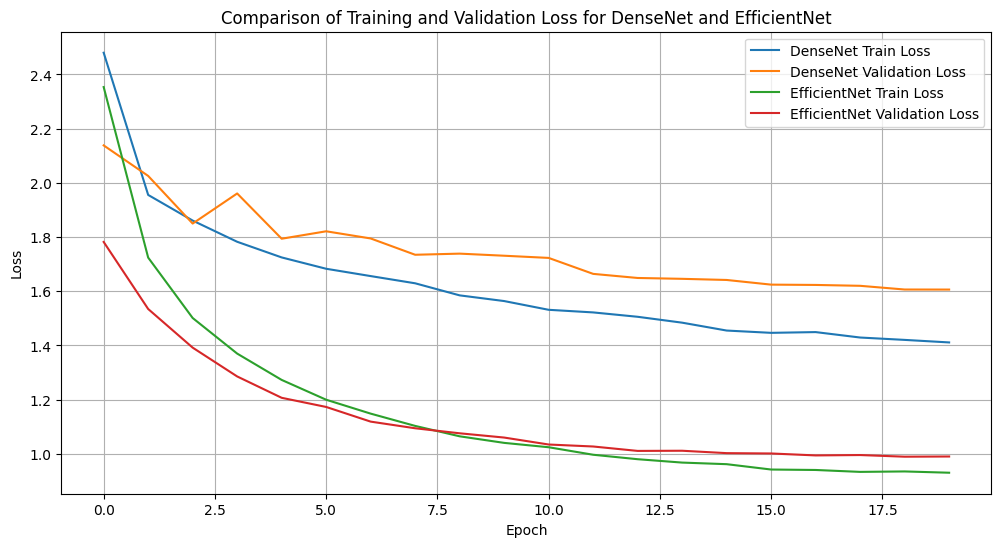

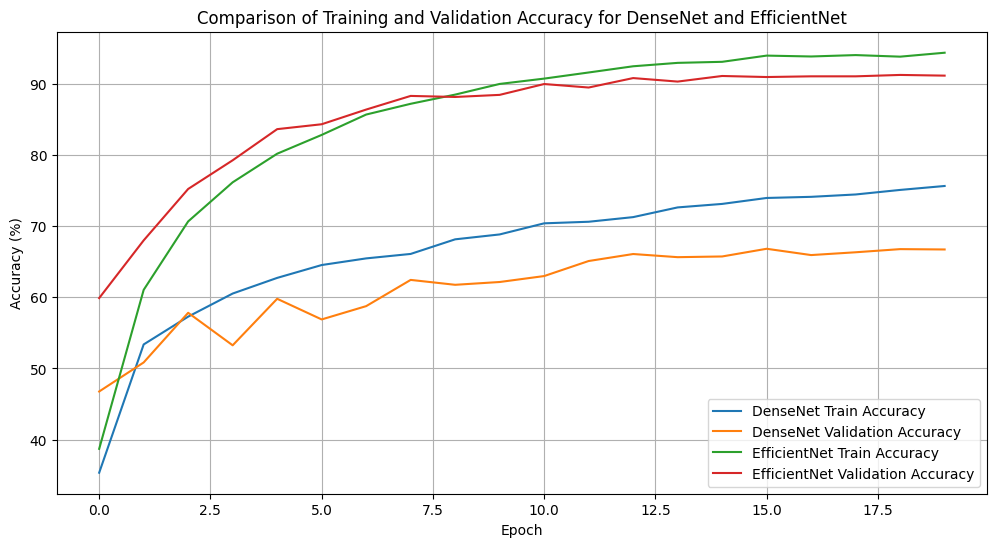

In [ ]:
import matplotlib.pyplot as plt

# Plot Combined Loss Curves
plt.figure(figsize=(12, 6))
plt.plot(train_losses_densenet, label="DenseNet Train Loss")
plt.plot(val_losses_densenet, label="DenseNet Validation Loss")
plt.plot(train_losses_efficientnet, label="EfficientNet Train Loss")
plt.plot(val_losses_efficientnet, label="EfficientNet Validation Loss")
plt.title("Comparison of Training and Validation Loss for DenseNet and EfficientNet")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot Combined Accuracy Curves
plt.figure(figsize=(12, 6))
plt.plot(train_accuracies_densenet, label="DenseNet Train Accuracy")
plt.plot(val_accuracies_densenet, label="DenseNet Validation Accuracy")
plt.plot(train_accuracies_efficientnet, label="EfficientNet Train Accuracy")
plt.plot(val_accuracies_efficientnet, label="EfficientNet Validation Accuracy")
plt.title("Comparison of Training and Validation Accuracy for DenseNet and EfficientNet")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

### Confusion Matrix for ResNet Model

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.2 MB/s eta 0:00:00


Predicting on test set (ResNet): 100%|██████████| 36/36 [00:12<00:00,  2.96it/s]


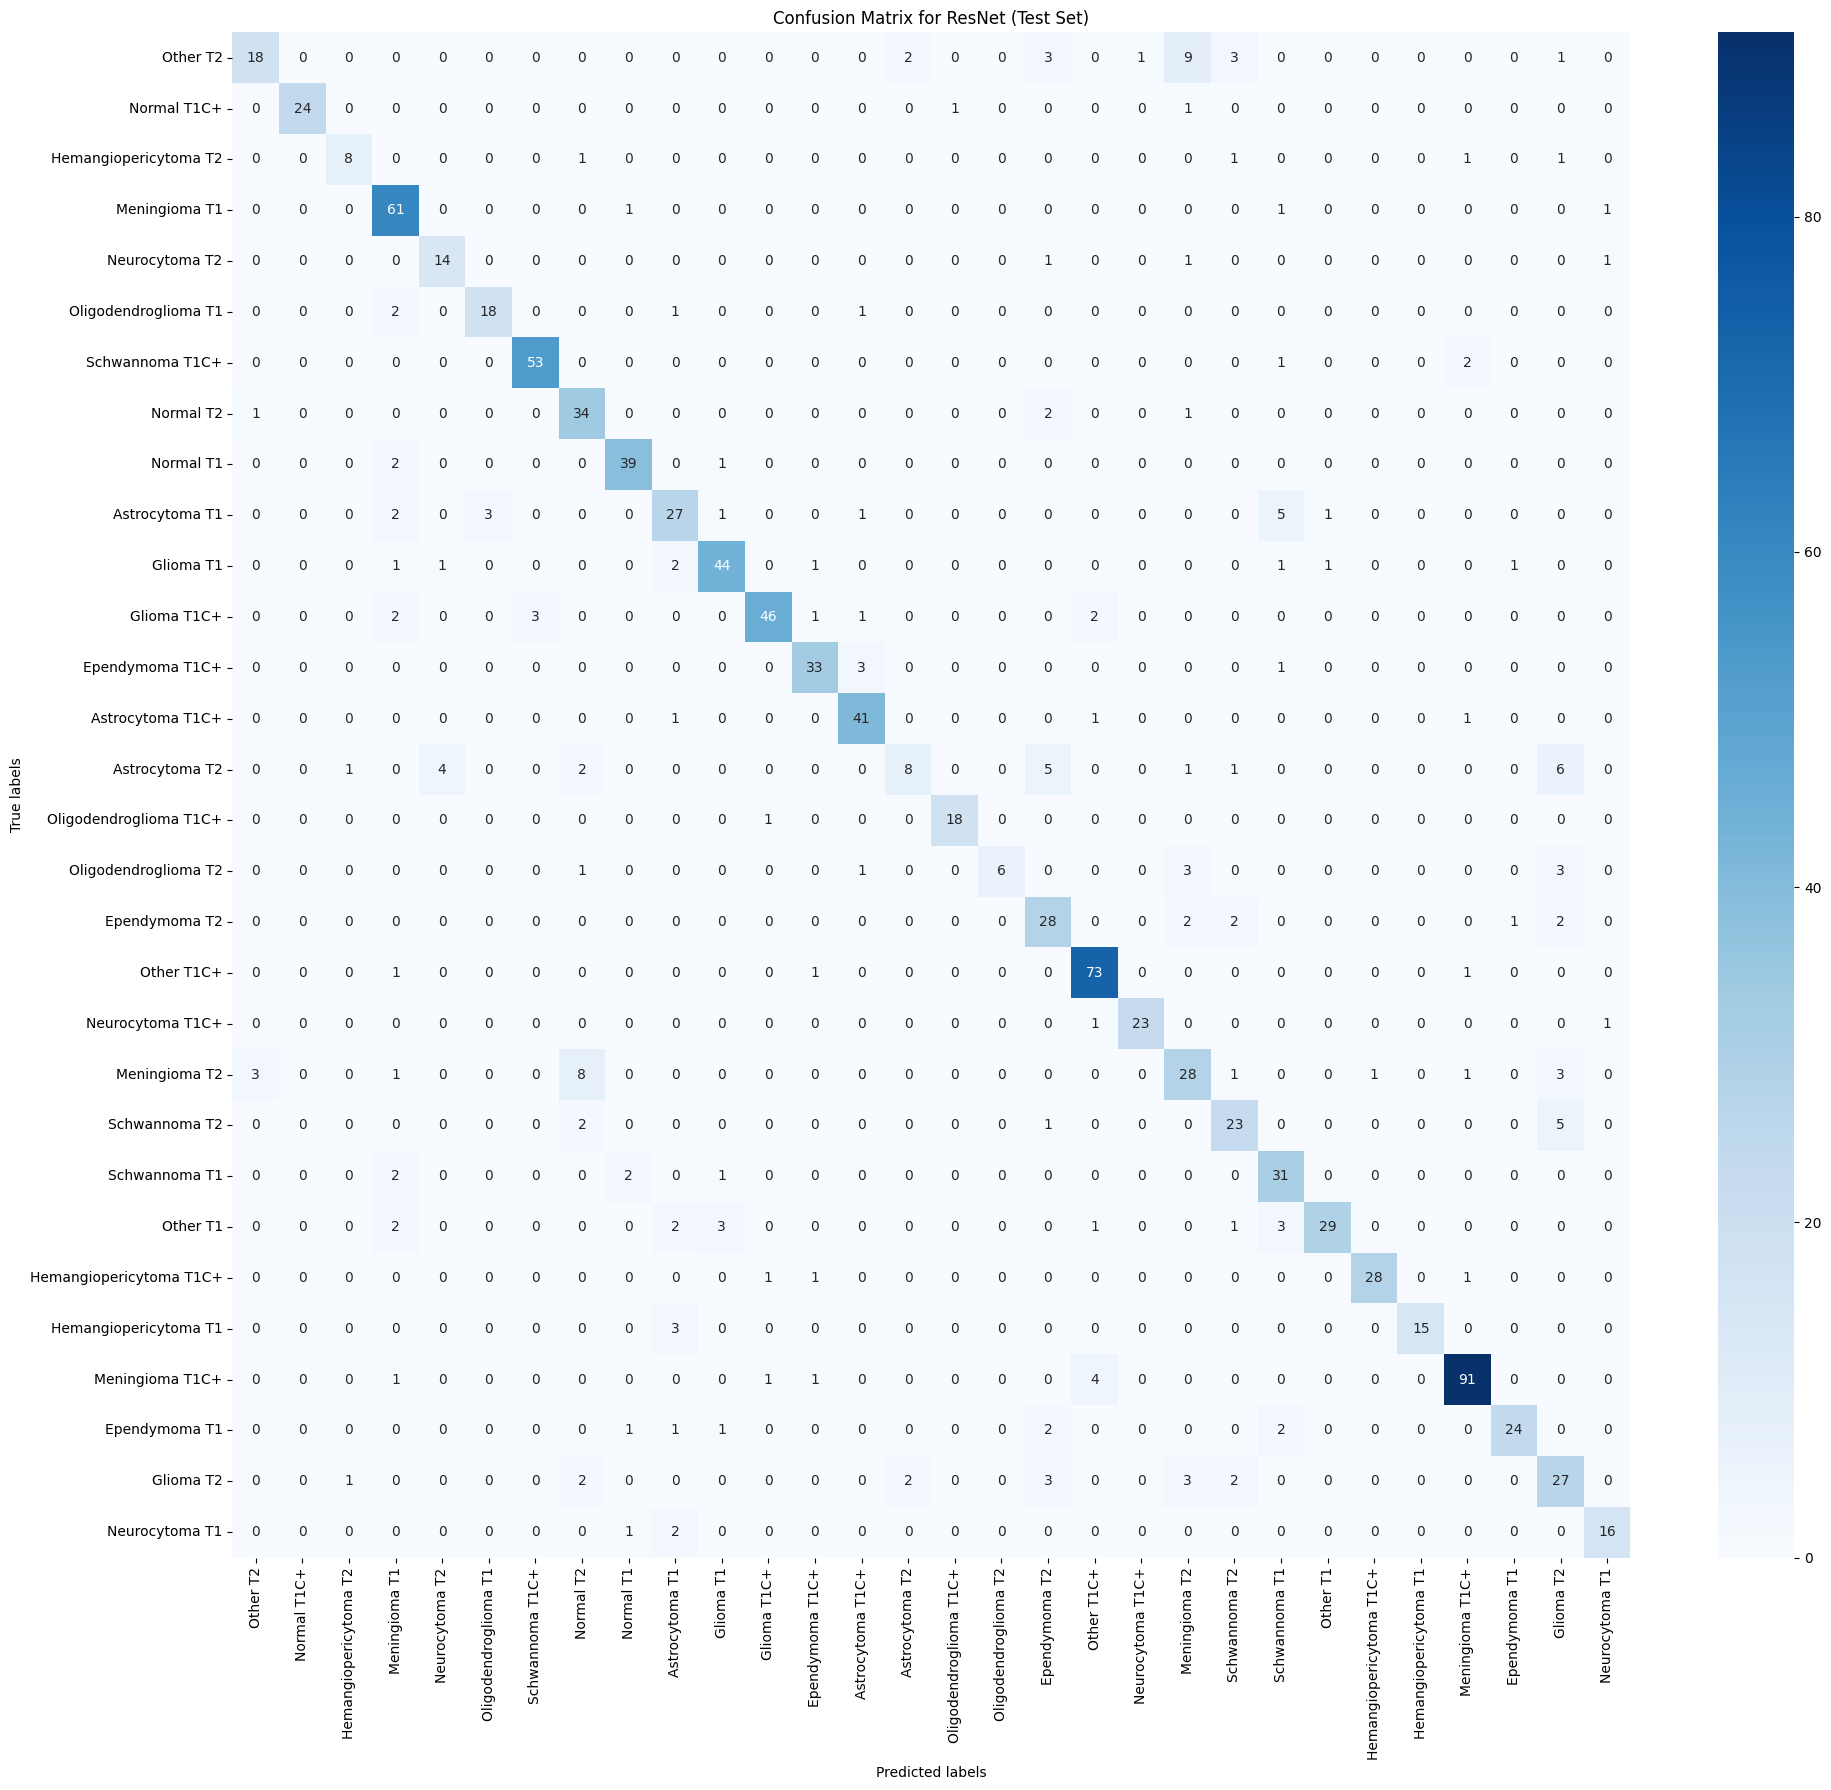

In [ ]:
import sys
!{sys.executable} -m pip install torchmetrics
from torchmetrics.classification import MulticlassConfusionMatrix
import seaborn as sns

# Load the best fine-tuned ResNet model
model_ft.load_state_dict(torch.load("best_finetuned_model.pth"))
model_ft.eval()

all_preds_resnet = []
all_labels_resnet = []

print("Collecting predictions for ResNet confusion matrix...")

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Predicting on test set (ResNet)"):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_ft(images)
        _, predicted = torch.max(outputs, 1)

        all_preds_resnet.extend(predicted.cpu().numpy())
        all_labels_resnet.extend(labels.cpu().numpy())

# Calculate confusion matrix
confmat_resnet = MulticlassConfusionMatrix(num_classes=num_of_classes).to(device)
confmat_tensor_resnet = confmat_resnet(torch.tensor(all_preds_resnet).to(device), torch.tensor(all_labels_resnet).to(device))

# Plotting the confusion matrix
plt.figure(figsize=(20, 18))
sns.heatmap(
    confmat_tensor_resnet.cpu().numpy(),
    annot=True,
    fmt='g',
    cmap='Blues',
    xticklabels=list(label_to_index.keys()),
    yticklabels=list(label_to_index.keys())
)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix for ResNet (Test Set)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Confusion Matrix for EfficientNet B0 Model

In [ ]:
from torchmetrics.classification import MulticlassConfusionMatrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the best fine-tuned EfficientNet model
efficientnet_model.load_state_dict(torch.load("best_efficientnet_finetuned_model.pth"))
efficientnet_model.eval()

all_preds_efficientnet = []
all_labels_efficientnet = []

print("Collecting predictions for EfficientNet confusion matrix...")

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Predicting on test set (EfficientNet)"):
        images = images.to(device)
        labels = labels.to(device)

        outputs = efficientnet_model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds_efficientnet.extend(predicted.cpu().numpy())
        all_labels_efficientnet.extend(labels.cpu().numpy())

# Calculate confusion matrix
confmat_efficientnet = MulticlassConfusionMatrix(num_classes=num_of_classes).to(device)
confmat_tensor_efficientnet = confmat_efficientnet(torch.tensor(all_preds_efficientnet).to(device), torch.tensor(all_labels_efficientnet).to(device))

# Plotting the confusion matrix
plt.figure(figsize=(20, 18))
sns.heatmap(
    confmat_tensor_efficientnet.cpu().numpy(),
    annot=True,
    fmt='g',
    cmap='Blues',
    xticklabels=list(label_to_index.keys()),
    yticklabels=list(label_to_index.keys())
)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix for EfficientNet B0 (Test Set)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Precision, Recall, and F1-Score for EfficientNet B0 Model

In [ ]:
from torchmetrics.classification import MulticlassPrecision, MulticlassRecall, MulticlassF1Score

# Ensure the model is loaded and in evaluation mode
efficientnet_model.load_state_dict(torch.load("best_efficientnet_finetuned_model.pth"))
efficientnet_model.eval()

# Initialize metrics
precision_metric = MulticlassPrecision(num_classes=num_of_classes, average='macro').to(device)
recall_metric = MulticlassRecall(num_classes=num_of_classes, average='macro').to(device)
f1_metric = MulticlassF1Score(num_classes=num_of_classes, average='macro').to(device)

print("Calculating Precision, Recall, and F1-Score for EfficientNet...")

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating EfficientNet on test set"):
        images = images.to(device)
        labels = labels.to(device)

        outputs = efficientnet_model(images)
        _, predicted = torch.max(outputs, 1)

        precision_metric.update(predicted, labels)
        recall_metric.update(predicted, labels)
        f1_metric.update(predicted, labels)

macro_precision = precision_metric.compute()
macro_recall = recall_metric.compute()
macro_f1 = f1_metric.compute()

print(f"\nEfficientNet Macro Precision: {macro_precision.item():.4f}")
print(f"EfficientNet Macro Recall: {macro_recall.item():.4f}")
print(f"EfficientNet Macro F1-Score: {macro_f1.item():.4f}")

### Comprehensive Evaluation for EfficientNet B0 Model (Classification Report and Confusion Matrix)

Evaluating EfficientNet for report: 100%|██████████| 36/36 [00:05<00:00,  6.86it/s]



Classification Report for EfficientNet B0:
                         precision    recall  f1-score   support

               Other T2       0.81      0.78      0.79        37
            Normal T1C+       1.00      0.96      0.98        26
  Hemangiopericytoma T2       1.00      0.67      0.80        12
          Meningioma T1       0.91      0.94      0.92        64
         Neurocytoma T2       0.71      0.88      0.79        17
   Oligodendroglioma T1       0.95      0.91      0.93        22
        Schwannoma T1C+       0.96      0.98      0.97        56
              Normal T2       0.88      1.00      0.94        38
              Normal T1       0.97      0.93      0.95        42
         Astrocytoma T1       0.97      0.88      0.92        40
              Glioma T1       0.92      0.85      0.88        52
            Glioma T1C+       0.96      0.95      0.95        55
        Ependymoma T1C+       0.97      0.92      0.94        37
       Astrocytoma T1C+       0.89      0.95 

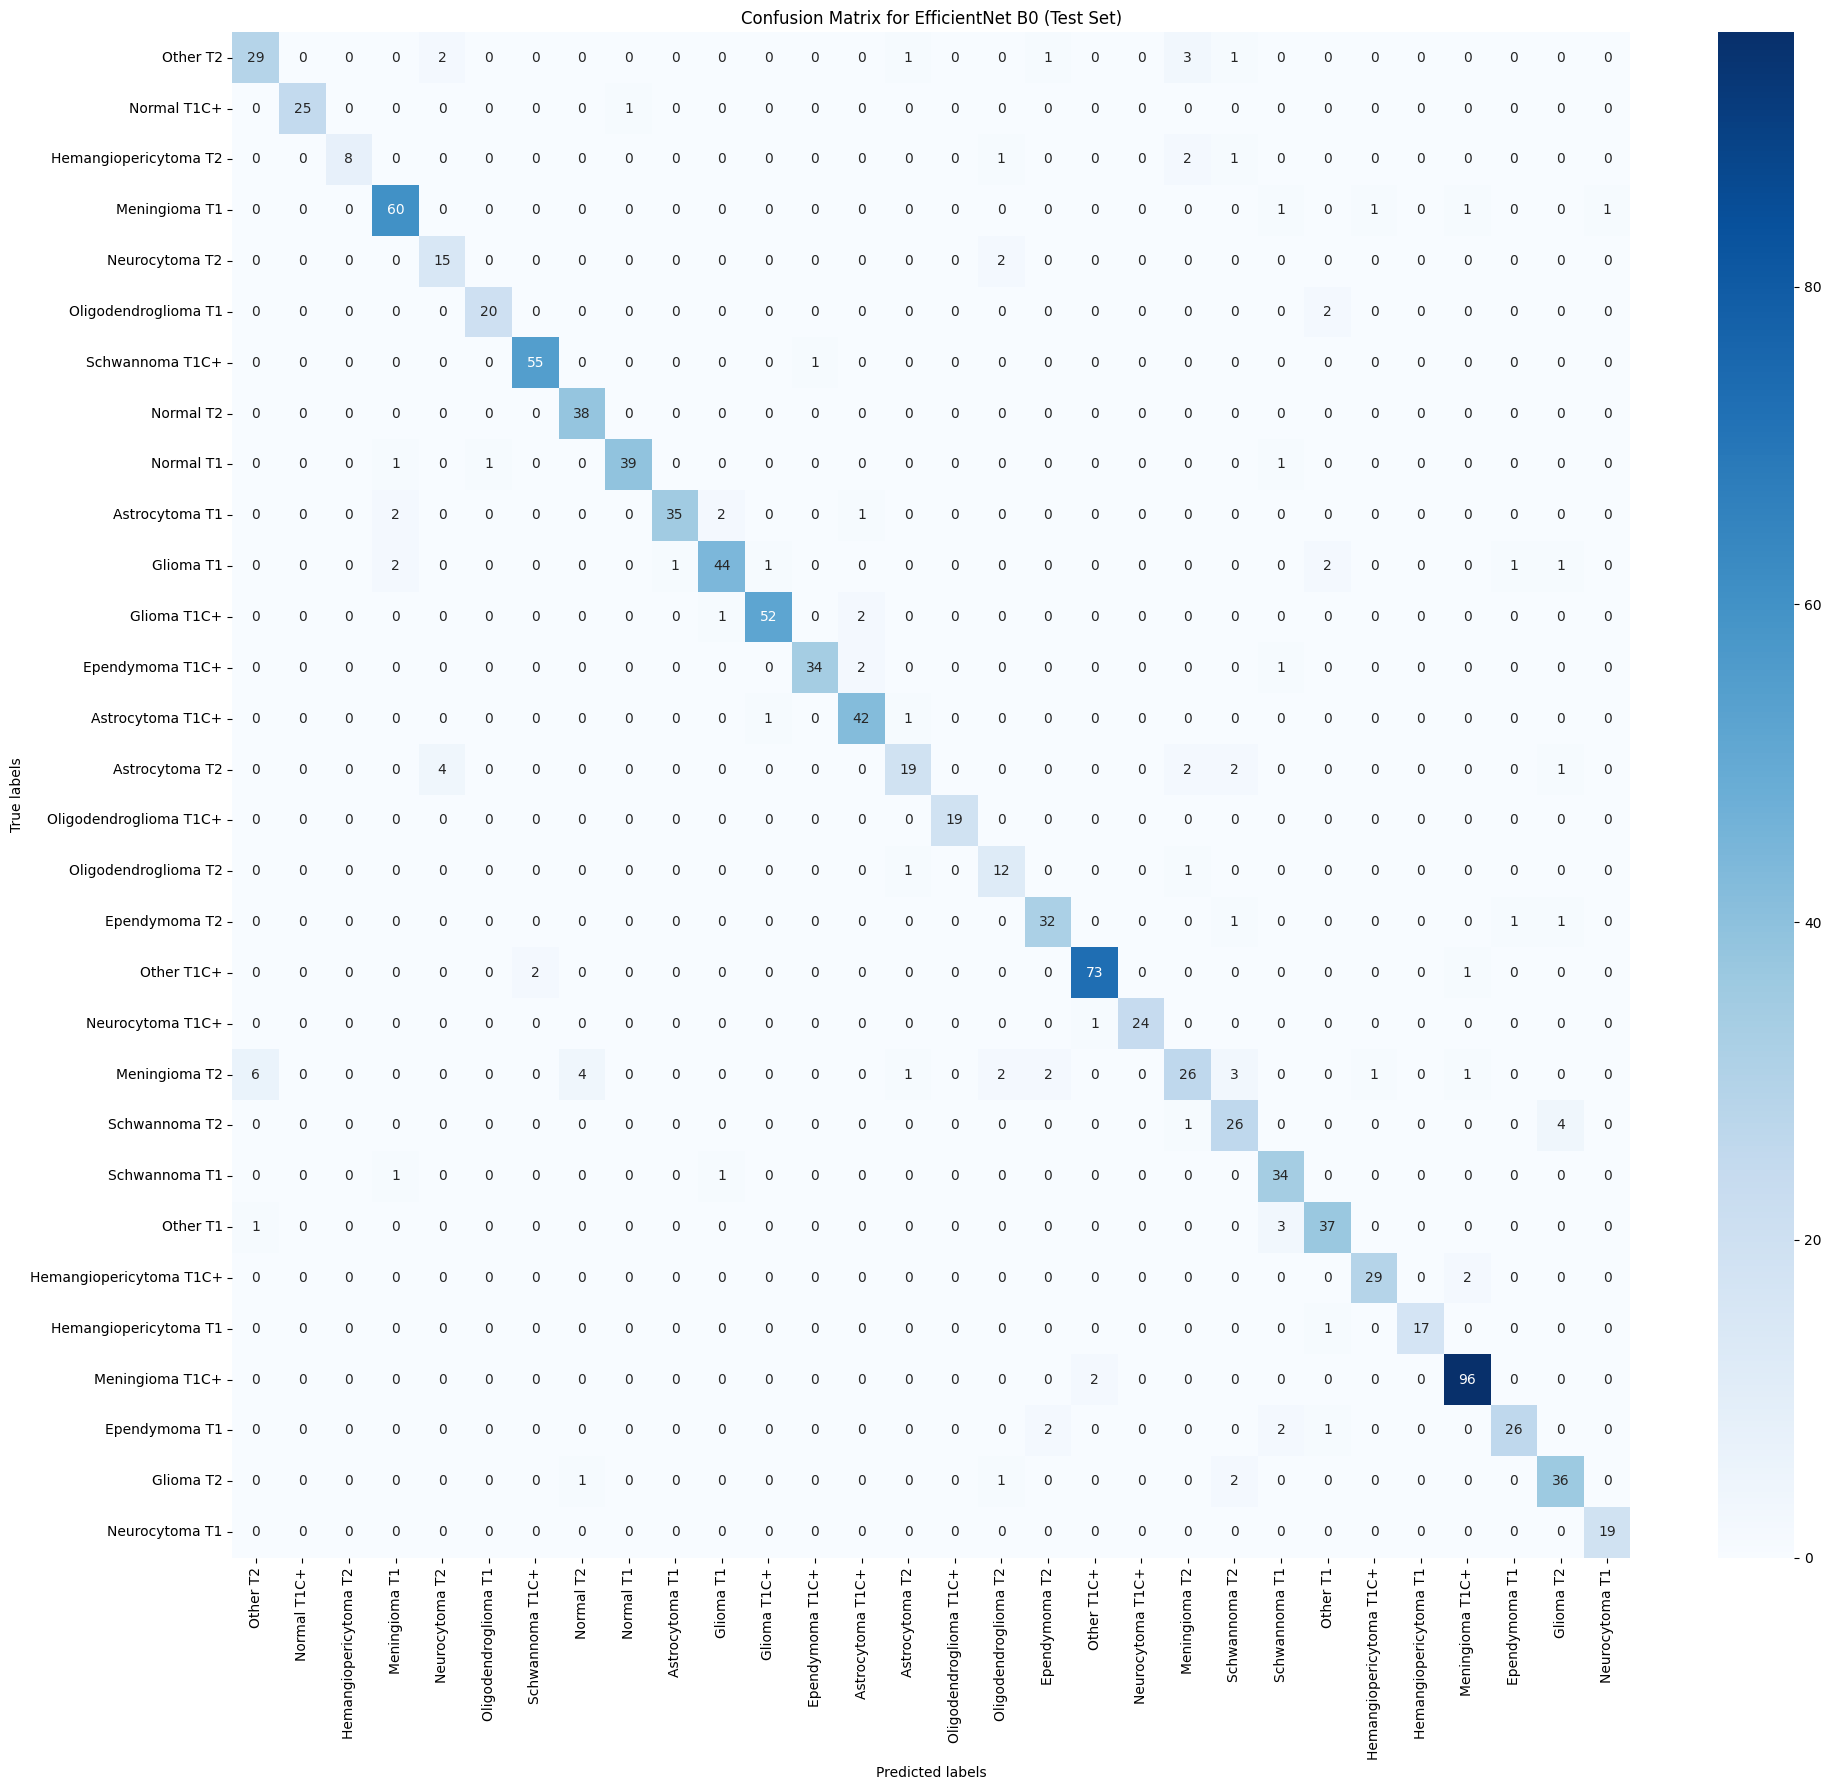

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure the model is loaded and in evaluation mode
efficientnet_model.load_state_dict(torch.load("best_efficientnet_finetuned_model.pth"))
efficientnet_model.eval()

all_preds_efficientnet_eval = []
all_labels_efficientnet_eval = []

print("Collecting predictions for comprehensive evaluation of EfficientNet...")

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating EfficientNet for report"):
        images = images.to(device)
        labels = labels.to(device)

        outputs = efficientnet_model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds_efficientnet_eval.extend(predicted.cpu().numpy())
        all_labels_efficientnet_eval.extend(labels.cpu().numpy())

# Convert to numpy arrays
y_true = np.array(all_labels_efficientnet_eval)
y_pred = np.array(all_preds_efficientnet_eval)

# Generate and print the classification report
print("\nClassification Report for EfficientNet B0:")
print(classification_report(y_true, y_pred, target_names=list(label_to_index.keys()), zero_division=0))

# Generate and plot the confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 18))
sns.heatmap(
    cm,
    annot=True,
    fmt='g',
    cmap='Blues',
    xticklabels=list(label_to_index.keys()),
    yticklabels=list(label_to_index.keys())
)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix for EfficientNet B0 (Test Set)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### EfficientNet B0 Inference Pipeline

In [ ]:
import torch.nn.functional as F
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def predict_tumor_type(image_path, model, transform, label_mapping, device):
    model.eval() # Set the model to evaluation mode

    # Load and transform the image
    image = Image.open(image_path).convert("RGB")
    if transform:
        image_tensor = transform(image)
    else:
        image_tensor = transforms.ToTensor()(image) # Fallback to basic ToTensor

    # Add batch dimension and move to device
    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)

    # Apply softmax to get probabilities
    probabilities = F.softmax(outputs, dim=1)

    # Get the predicted class and its confidence
    confidence, predicted_idx = torch.max(probabilities, 1)

    # Map the predicted index back to the label (tumor type)
    predicted_label = label_mapping[predicted_idx.item()]

    return predicted_label, confidence.item()


Now, let's use the `predict_tumor_type` function with a sample image from our test set and visualize the prediction.

In [ ]:
# Select a random image from the test set for demonstration
sample_test_image_path = test_df.sample(1, random_state=seed)['image_path'].iloc[0]

# Perform prediction
predicted_label, confidence = predict_tumor_type(
    sample_test_image_path,
    efficientnet_model,
    test_transform,
    index_to_label,
    device
)

print(f"Sample Image: {sample_test_image_path}")
print(f"Predicted Tumor Type: {predicted_label}")
print(f"Confidence: {confidence:.4f}")

# Display the image with the prediction
plt.figure(figsize=(6, 6))
img = Image.open(sample_test_image_path)
plt.imshow(img)
plt.title(f"Prediction: {predicted_label} (Confidence: {confidence:.2f})")
plt.axis('off')
plt.show()


In [ ]:
import torch

# Save the best EfficientNet fine-tuned model before creating app.py
torch.save(efficientnet_model.state_dict(), "best_efficientnet_finetuned_model.pth")
print("EfficientNet model saved to 'best_efficientnet_finetuned_model.pth'")

EfficientNet model saved to 'best_efficientnet_finetuned_model.pth'


In [ ]:
%%writefile app.py

import streamlit as st
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import torch.nn.functional as F
from PIL import Image
import numpy as np

# --- Configuration and Mappings (re-creating necessary variables) ---
# These were derived from earlier notebook cells.
# In a real deployment, these might be loaded from a config file or a database.

unique_labels = [
    'Neurocytoma T2', 'Oligodendroglioma T2', 'Astrocytoma T1',
    'Schwannoma T1', 'Oligodendroglioma T1C+', 'Glioma T1',
    'Schwannoma T2', 'Normal T1C+', 'Glioma T2', 'Meningioma T1',
    'Ependymoma T1', 'Hemangiopericytoma T1C+', 'Ependymoma T1C+',
    'Other T1', 'Astrocytoma T1C+', 'Schwannoma T1C+',
    'Neurocytoma T1C+', 'Other T1C+', 'Hemangiopericytoma T1',
    'Meningioma T1C+', 'Normal T1', 'Meningioma T2',
    'Hemangiopericytoma T2', 'Normal T2', 'Other T2',
    'Ependymoma T2', 'Glioma T1C+', 'Astrocytoma T2',
    'Oligodendroglioma T1', 'Neurocytoma T1'
]

index_to_label = {index: label for index, label in enumerate(unique_labels)}
num_of_classes = len(unique_labels)

# --- Model Definition (EfficientNet B0) ---
def load_efficientnet_model(num_classes, model_path):
    # Load a pre-trained EfficientNet B0 model
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

    # Modify the final classification layer
    num_ftrs_efficientnet = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs_efficientnet, num_classes)

    # Load the trained weights
    model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
    model.eval() # Set the model to evaluation mode
    return model

# --- Image Transformation ---
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Standard ImageNet normalization
])

# --- Prediction Function ---
def predict_tumor_type(image, model, transform, label_mapping):
    # Apply transformations
    image_tensor = transform(image).unsqueeze(0) # Add batch dimension

    with torch.no_grad():
        outputs = model(image_tensor)

    # Apply softmax to get probabilities
    probabilities = F.softmax(outputs, dim=1)

    # Get the predicted class and its confidence
    confidence, predicted_idx = torch.max(probabilities, 1)

    # Map the predicted index back to the label (tumor type)
    predicted_label = label_mapping[predicted_idx.item()]

    return predicted_label, confidence.item()

# --- Streamlit App ---
st.set_page_config(page_title="Brain Tumor Type Prediction", page_icon=":brain:")

st.title("🧠 Brain Tumor Type Prediction")
st.markdown("Upload an MRI image to predict the brain tumor type using a fine-tuned EfficientNet B0 model.")

# Load the model
model_path = "best_efficientnet_finetuned_model.pth" # Assuming the model is in the same directory
# Use st.cache_resource to load the model only once
@st.cache_resource
def get_model():
    return load_efficientnet_model(num_of_classes, model_path)

model = get_model()

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Uploaded Image", use_column_width=True)
    st.write("")
    st.write("Classifying...")

    predicted_label, confidence = predict_tumor_type(image, model, transform, index_to_label)

    st.success(f"Prediction: **{predicted_label}**")
    st.info(f"Confidence: **{confidence:.2f}**")

    st.markdown("--- Request new prediction ---")


Writing app.py


In [ ]:
from google.colab import files
files.download('best_efficientnet_finetuned_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

To run the Streamlit application, execute the following command in your terminal. This command will start the Streamlit server, and you can then access the app through the provided URL.

```bash
streamlit run app.py
```

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 92.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 119.6 MB/s eta 0:00:00


After installing Streamlit, you can then run the `app.py` file from your terminal:

```bash
streamlit run app.py
```